#### Project Udemy Courses Analysis

In [ ]:
import numpy  as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving UdemyCoursesDataset.csv to UdemyCoursesDataset.csv


In [ ]:
df=pd.read_csv('UdemyCoursesDataset.csv')
df.head()

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
0,288942,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18T05:07:05Z,Musical Instruments
1,1170074,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12T19:06:34Z,Musical Instruments
2,1193886,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26T18:34:57Z,Musical Instruments
3,1116700,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21T23:48:18Z,Musical Instruments
4,1120410,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21T23:44:49Z,Musical Instruments


In [ ]:
df.tail(5)

,course_id,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject
3677,328960,Your Own Site in 45 Min: The Complete Wordpres...,True,120,1566,29,36,All Levels,4 hours,2015-04-20T22:15:17Z,Web Development
3678,552700,Your Second Course on Piano: Two Handed Playing,True,70,1018,12,22,Beginner Level,5 hours,2015-10-26T20:04:21Z,Musical Instruments
3679,631754,Zend Framework 2: Learn the PHP framework ZF2 ...,True,40,723,130,37,All Levels,6.5 hours,2015-11-11T18:55:45Z,Web Development
3680,1225194,Zoho Books Gestion Financière d'Entreprise pas...,False,Free,229,0,33,All Levels,2 hours,2017-05-26T16:45:55Z,Business Finance
3681,964478,Zombie Apocalypse Photoshop Actions,True,50,12,1,15,All Levels,1.5 hours,2016-09-26T22:19:48Z,Graphic Design


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3682 entries, 0 to 3681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   course_id            3682 non-null   int64 
 1   course_title         3682 non-null   object
 2   is_paid              3682 non-null   bool  
 3   price                3682 non-null   object
 4   num_subscribers      3682 non-null   int64 
 5   num_reviews          3682 non-null   int64 
 6   num_lectures         3682 non-null   int64 
 7   level                3682 non-null   object
 8   content_duration     3682 non-null   object
 9   published_timestamp  3682 non-null   object
 10  subject              3682 non-null   object
dtypes: bool(1), int64(4), object(6)
memory usage: 291.4+ KB


In [ ]:
df.describe()

,course_id,num_subscribers,num_reviews,num_lectures
count,3.682000e+03,3682.000000,3682.000000,3682.000000
mean,6.766121e+05,3194.230310,156.093156,40.065182
std,3.436355e+05,9499.378361,934.957204,50.373299
min,8.324000e+03,0.000000,0.000000,0.000000
25%,4.078430e+05,110.250000,4.000000,15.000000
50%,6.885580e+05,911.500000,18.000000,25.000000
75%,9.617515e+05,2540.250000,67.000000,45.000000
max,1.282064e+06,268923.000000,27445.000000,779.000000


##Data Cleaning

In [ ]:
df.isnull().sum()

,0
course_id,0
course_title,0
is_paid,0
price,0
num_subscribers,0
num_reviews,0
num_lectures,0
level,0
content_duration,0
published_timestamp,0


## Check Dublicate

In [ ]:
df.duplicated().sum()

np.int64(6)

**The dataset dosent have null values but have duplicated**

In [ ]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
for x in df.index:
  if (df.loc[x, 'num_lectures']==0):
       df.drop(x, inplace = True)


drop the courses that has no lectures as it doesn't not make sense for the courses to not contain any lecture

In [ ]:
df['course_id'].nunique()

3671

we have two unique and unneeded columns('course id' and 'url) so we will drop them

In [ ]:
df.drop(columns=['course_id'],inplace=True)

In [ ]:
df.shape

(3671, 10)

## Data Transformation

In [ ]:
#changing the 'published_timestamp' to correct Datatye
df['published_timestamp'] = pd.to_datetime(df['published_timestamp'])
df['year'] = df['published_timestamp'].dt.year
df['month'] = df['published_timestamp'].dt.month



In [ ]:
df

,course_title,is_paid,price,num_subscribers,num_reviews,num_lectures,level,content_duration,published_timestamp,subject,year,month
0,#1 Piano Hand Coordination: Play 10th Ballad i...,True,35,3137,18,68,All Levels,1.5 hours,2014-09-18 05:07:05+00:00,Musical Instruments,2014,9
1,#10 Hand Coordination - Transfer Chord Ballad ...,True,75,1593,1,41,Intermediate Level,1 hour,2017-04-12 19:06:34+00:00,Musical Instruments,2017,4
2,#12 Hand Coordination: Let your Hands dance wi...,True,75,482,1,47,Intermediate Level,1.5 hours,2017-04-26 18:34:57+00:00,Musical Instruments,2017,4
3,#4 Piano Hand Coordination: Fun Piano Runs in ...,True,75,850,3,43,Intermediate Level,1 hour,2017-02-21 23:48:18+00:00,Musical Instruments,2017,2
4,#5 Piano Hand Coordination: Piano Runs in 2 ...,True,75,940,3,32,Intermediate Level,37 mins,2017-02-21 23:44:49+00:00,Musical Instruments,2017,2
...,...,...,...,...,...,...,...,...,...,...,...,...
3677,Your Own Site in 45 Min: The Complete Wordpres...,True,120,1566,29,36,All Levels,4 hours,2015-04-20 22:15:17+00:00,Web Development,2015,4
3678,Your Second Course on Piano: Two Handed Playing,True,70,1018,12,22,Beginner Level,5 hours,2015-10-26 20:04:21+00:00,Musical Instruments,2015,10
3679,Zend Framework 2: Learn the PHP framework ZF2 ...,True,40,723,130,37,All Levels,6.5 hours,2015-11-11 18:55:45+00:00,Web Development,2015,11
3680,Zoho Books Gestion Financière d'Entreprise pas...,False,Free,229,0,33,All Levels,2 hours,2017-05-26 16:45:55+00:00,Business Finance,2017,5


## EDA and Visualisation

## 1- HeatMap:



To illustrate the colleration between the features.



<Axes: >

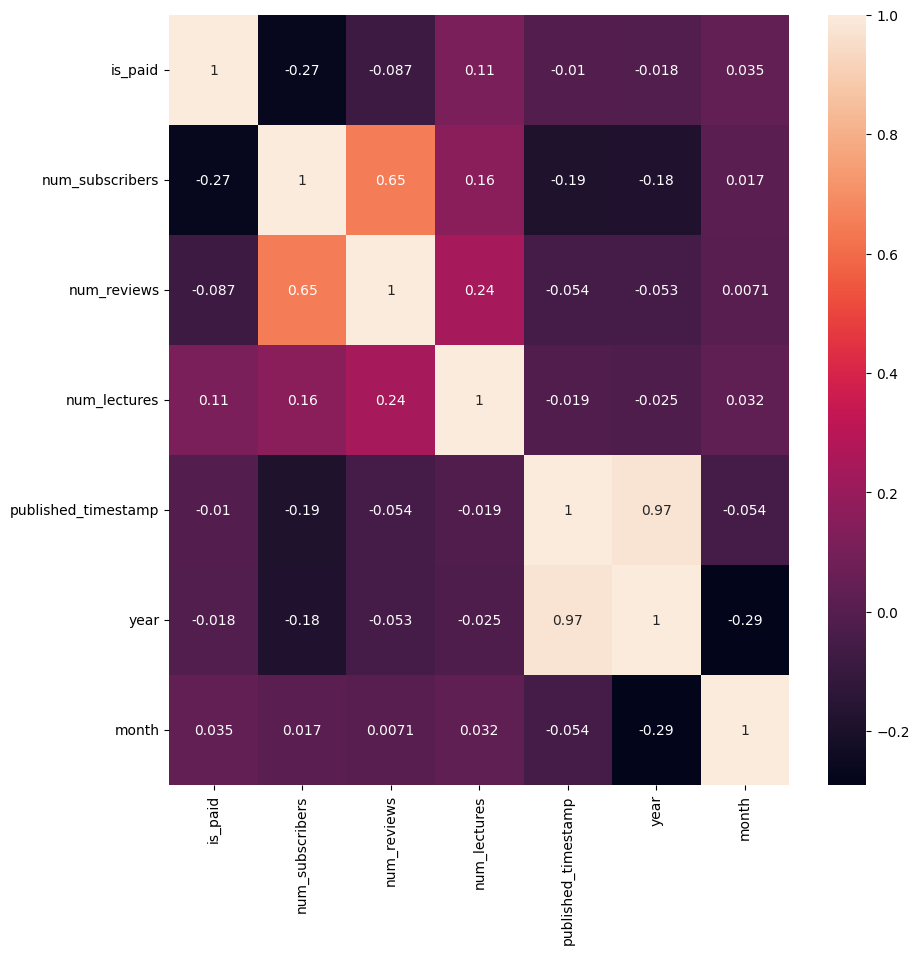

In [ ]:
numerical_df = df.select_dtypes(exclude=np.object_)

plt.figure(figsize=(10,10))

sns.heatmap(numerical_df.corr(), annot=True)

We can conclude from the HeatMap that 'num subscribers' column has a negative colleration with is paid which mean that free courses have more subscribers than paid ones.
we can also see that 'price' has a positive colleration with 'num lectures. Germini rses.csv Number of Paid and Free courses

## Number of Paid and Free courses

In [ ]:
df['is_paid'].value_counts()

,count
is_paid,
True,3361
False,310


/tmp/ipykernel_5539/1328789817.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="is_paid", data=df, palette="Set2")


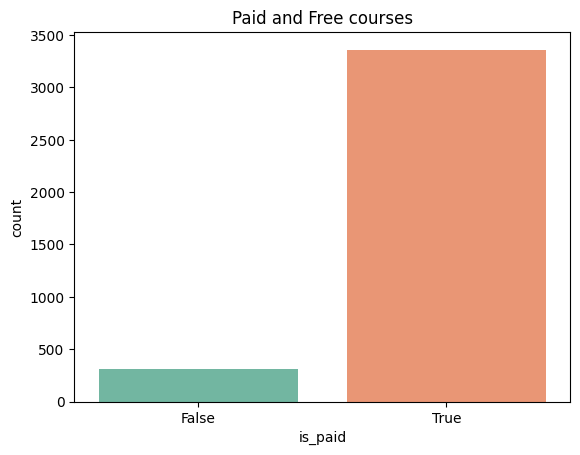

In [ ]:
sns.countplot(x="is_paid", data=df, palette="Set2")
plt.title("Paid and Free courses")
plt.show()

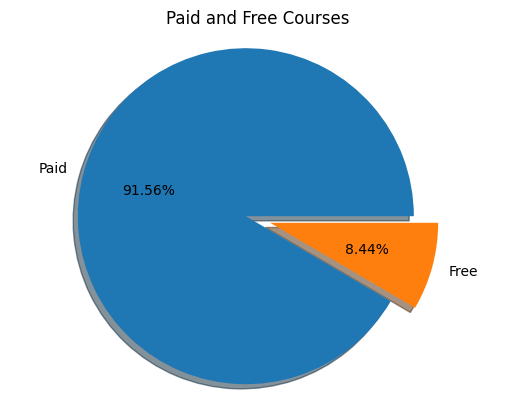

In [ ]:
import matplotlib.pyplot as plt

counts = df["is_paid"].value_counts()

plt.pie(
    counts,
    labels=("Paid", "Free"),
    autopct="%1.2f%%",
    shadow=True,
    explode=(0, 0.15)
)

plt.title("Paid and Free Courses")
plt.axis("equal")

plt.show()

We can see that most of the courses are paid. But which one are on demand?

Relation between paid courses and number of subscribers

/tmp/ipykernel_5539/1388276202.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


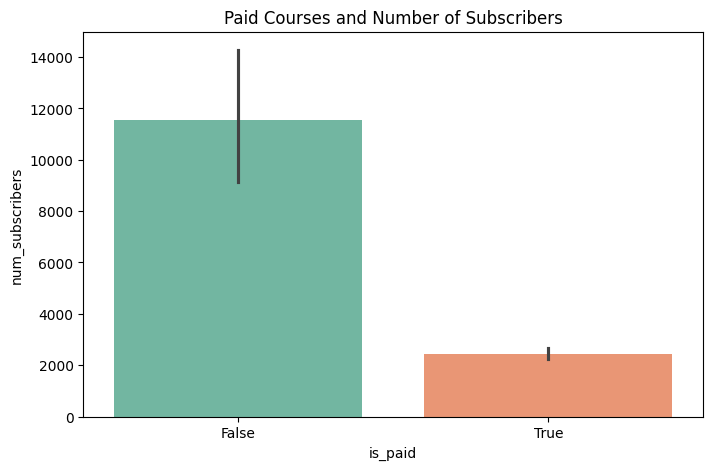

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="is_paid",
    y="num_subscribers",
    data=df,
    palette="Set2"
)

plt.title("Paid Courses and Number of Subscribers")
plt.show()

## number of cources in each subject

In [ ]:
df['subject'].value_counts()

,count
subject,
Web Development,1199
Business Finance,1190
Musical Instruments,680
Graphic Design,602


/tmp/ipykernel_5539/515995617.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


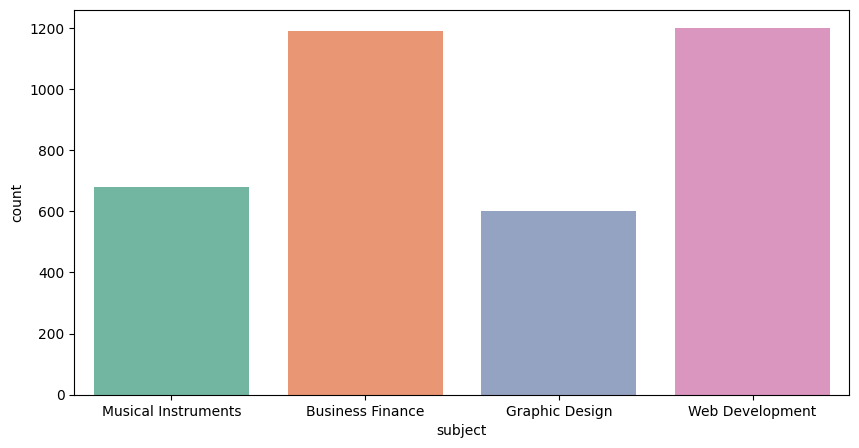

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="subject",
    data=df,
    palette="Set2"
)

plt.show()

percent of courses

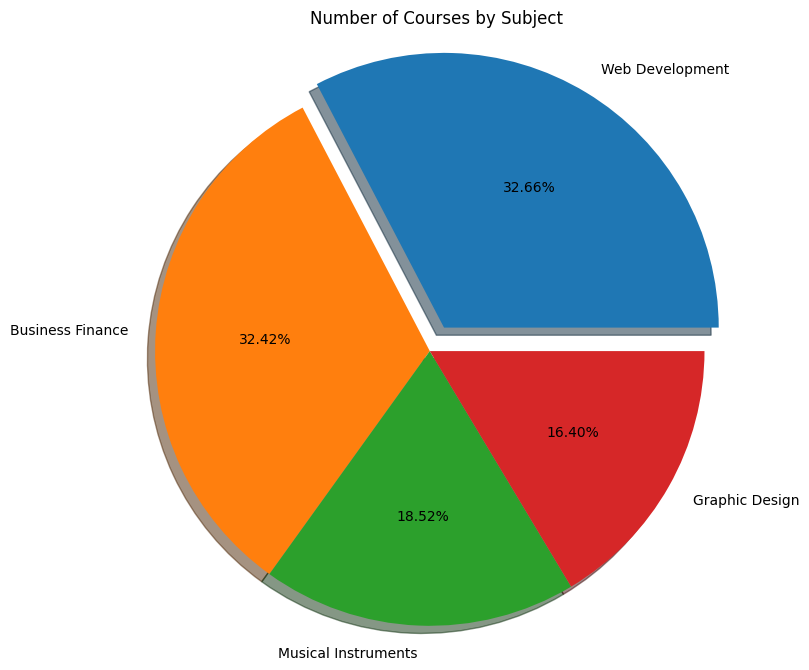

In [ ]:
import matplotlib.pyplot as plt

counts = df['subject'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.2f%%",
    shadow=True,
    explode=(0.1, 0, 0, 0)
)

plt.title("Number of Courses by Subject")
plt.axis("equal")

plt.show()

Web Development and Business Finance have the bigger number of courses and they are almost equal.

Which subject has the max number of Subscribers?

In [ ]:
df.groupby('subject')['num_subscribers'].sum().sort_values(ascending=False)

,num_subscribers
subject,
Web Development,7937287
Business Finance,1868711
Graphic Design,1063148
Musical Instruments,846689


/tmp/ipykernel_5539/1913557049.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


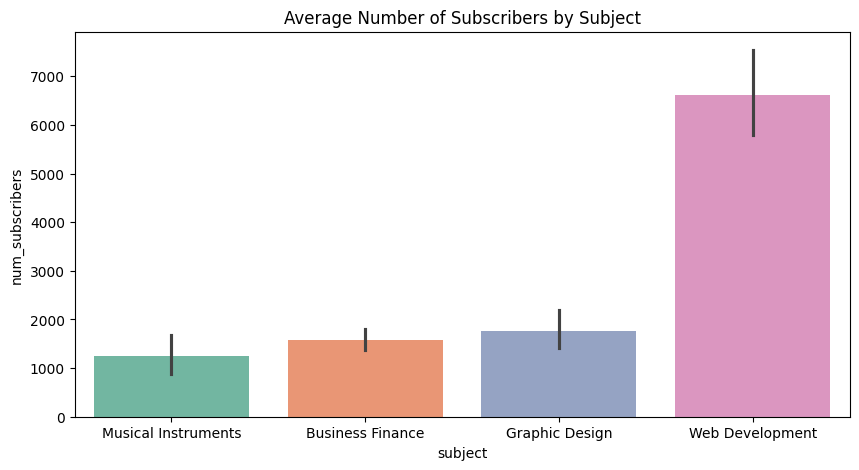

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    x="subject",
    y="num_subscribers",
    data=df,palette="Set2")
plt.title("Average Number of Subscribers by Subject")
plt.show()


Which subject has the max number of Subscribers?with is_paid

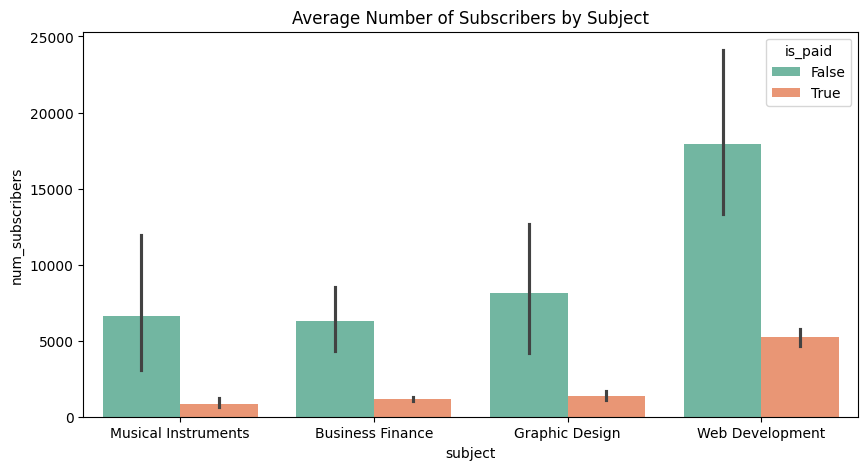

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    x="subject",
    y="num_subscribers",
    hue="is_paid",
    data=df, palette="Set2")
plt.title("Average Number of Subscribers by Subject")
plt.show()

it is obvious that web development and Free courses are the most popular to the subscribers.



## Number of courses in each level

/tmp/ipykernel_5539/393037516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


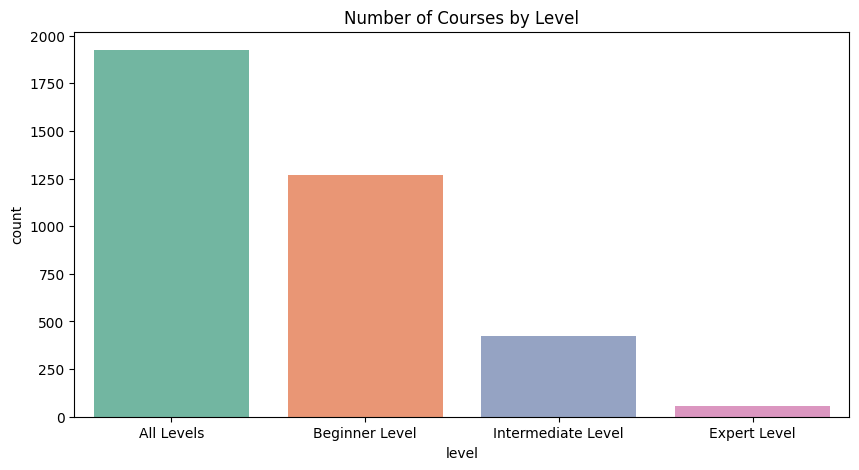

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(
    x="level", order=df["level"].value_counts().index,
    data=df, palette="Set2"
)
plt.title("Number of Courses by Level")
plt.show()

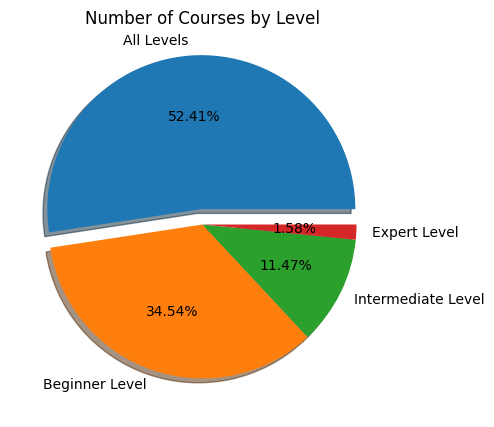

In [ ]:
plt.figure(figsize=(10,5))
plt.pie(
    df["level"].value_counts(),
    labels=df["level"].value_counts().index,
    autopct="%1.2f%%",
    shadow=True,
    explode=(0.1, 0, 0, 0)
)
plt.title("Number of Courses by Level")
plt.show()

We can conclude that the bigger number of courses are in all levels and only few courses are in expert level.



## distribution of course prices

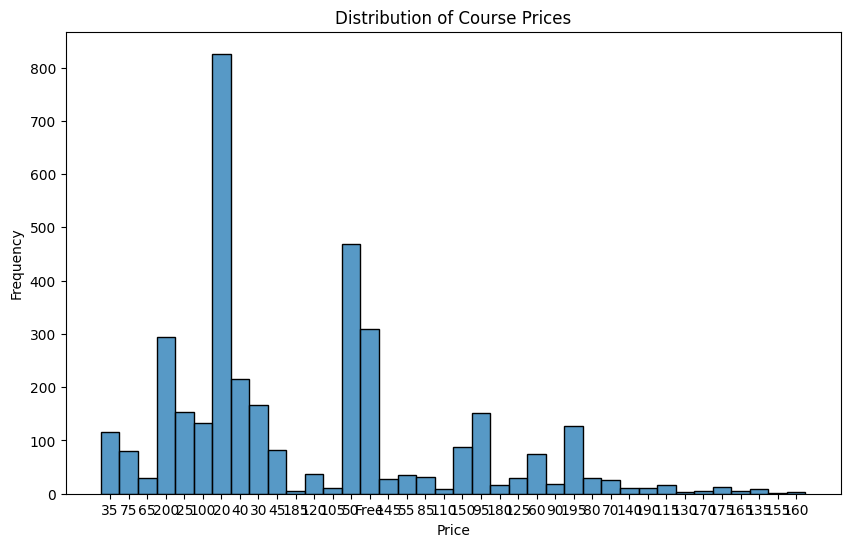

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,
    x="price", bins=20)
plt.title("Distribution of Course Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## Relation Between Price and Number of curces Subscribes

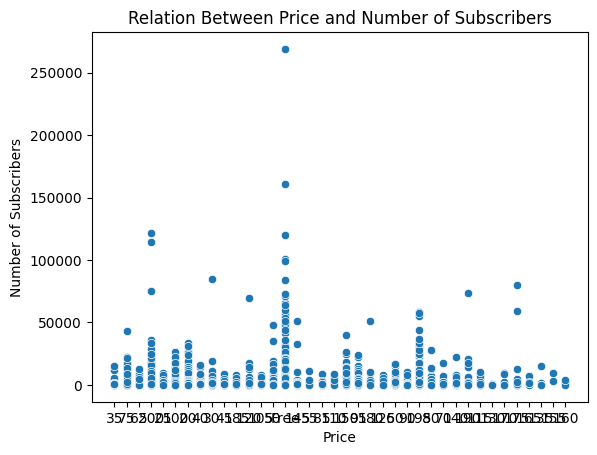

In [ ]:
sns.scatterplot(data=df,
    x="price", y="num_subscribers")
plt.title("Relation Between Price and Number of Subscribers")
plt.xlabel("Price")
plt.ylabel("Number of Subscribers")
plt.show()

most popular courses tend to be either free or very expensive.



## Which course duration and number of lectures does subscribers prefer?

Text(0.5, 0, 'Number of Lectures')

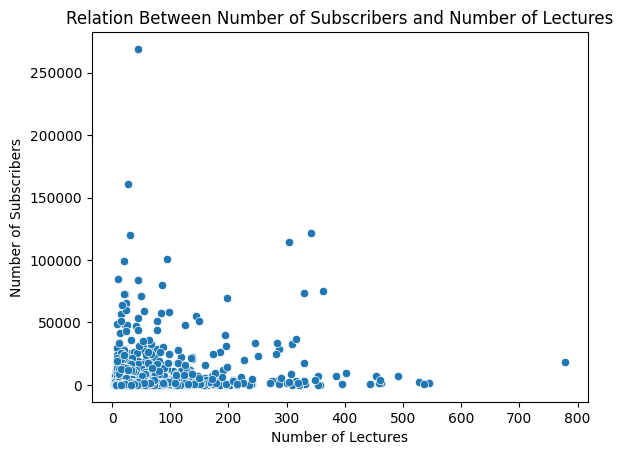

In [ ]:
sns.scatterplot(data=df,
    y="num_subscribers", x="num_lectures")
plt.title("Relation Between Number of Subscribers and Number of Lectures")
plt.ylabel("Number of Subscribers")
plt.xlabel("Number of Lectures")

Text(0.5, 0, 'Content Duration')

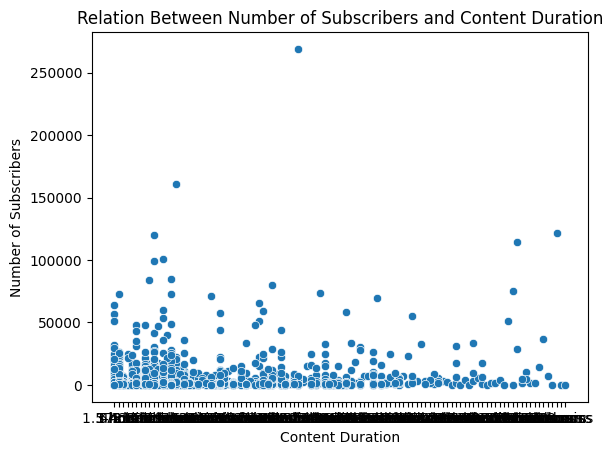

In [ ]:
sns.scatterplot(data=df,
    y="num_subscribers", x="content_duration")
plt.title("Relation Between Number of Subscribers and Content Duration")
plt.ylabel("Number of Subscribers")
plt.xlabel("Content Duration")

Plots with the number of lectures and content duration show that most popular courses are shorter, and have fewer number of content hours.

## Total price of courses over the years

Text(0, 0.5, 'Total Price')

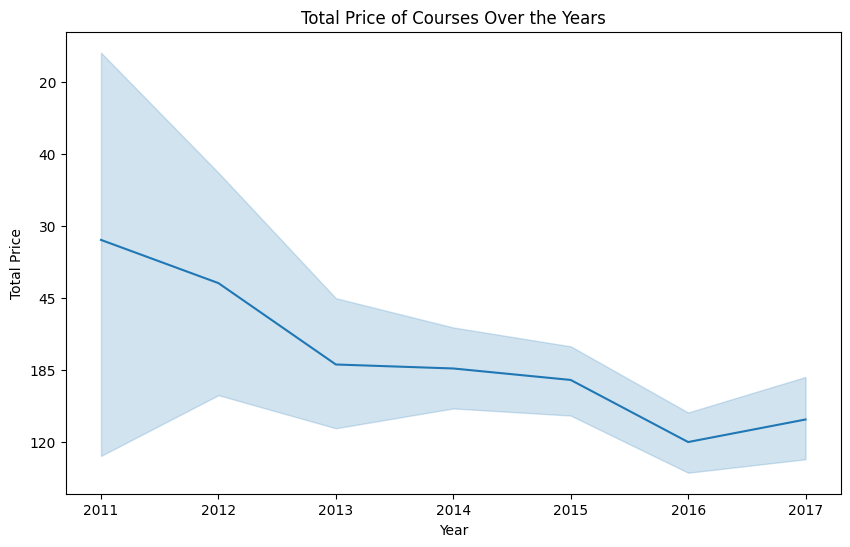

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df,
    x="year", y="price")
plt.title("Total Price of Courses Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Price")

## Duration of curces published over months

/tmp/ipykernel_5539/3472576362.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, palette="Set2", x='month')


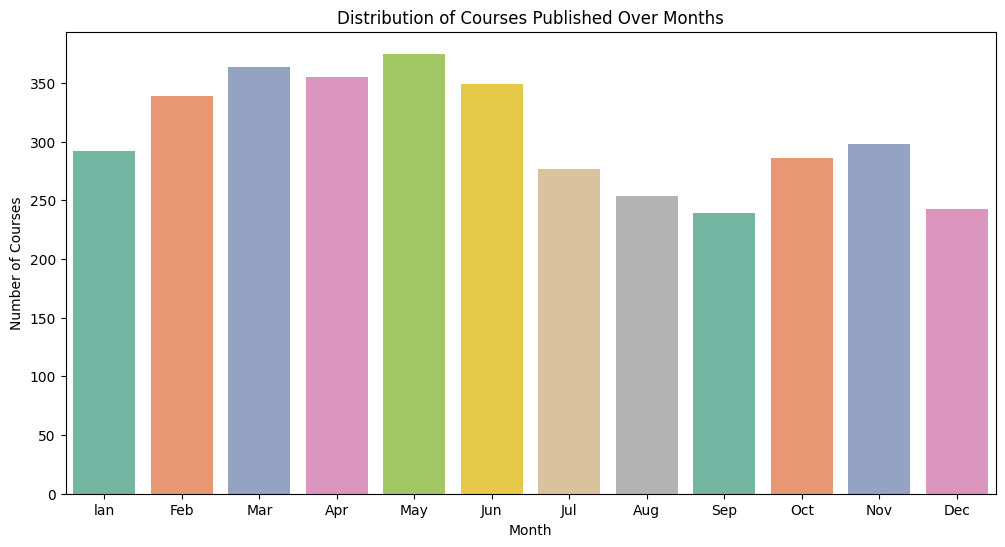

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, palette="Set2", x='month')
plt.title("Distribution of Courses Published Over Months")
plt.xlabel('Month')
plt.ylabel('Number of Courses')
plt.xticks (range(0, 12), ['lan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

## waht the most 5 cources the have high subscribed?

/tmp/ipykernel_5539/3781501461.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.sort_values(by="num_subscribers", ascending=False).head(5),palette="Set2",


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

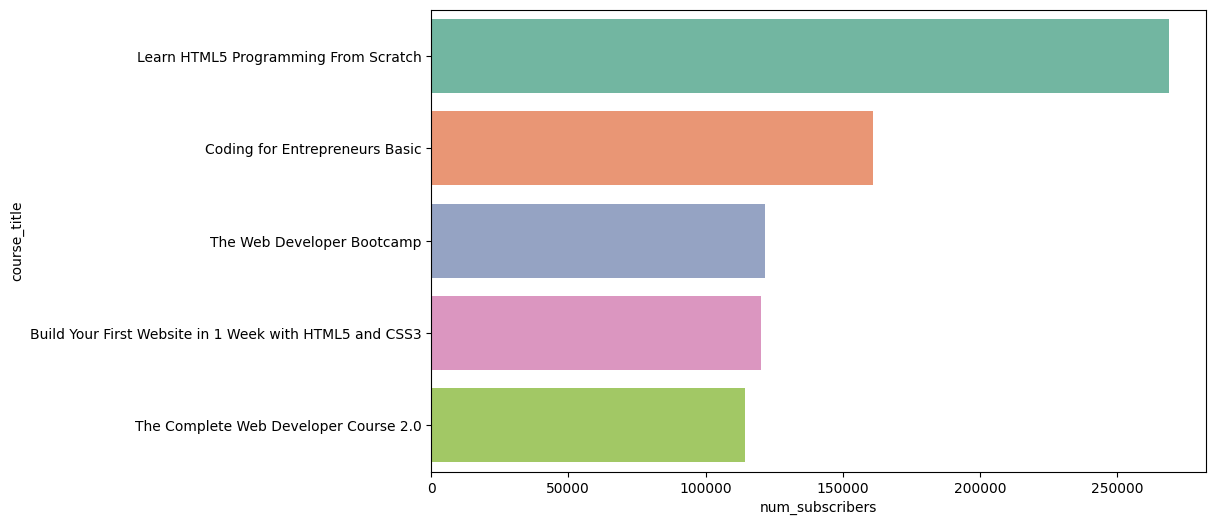

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df.sort_values(by="num_subscribers", ascending=False).head(5),palette="Set2",
    x="num_subscribers", y="course_title")
plt

## top 20 cources that have high prices

## count of courses price

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

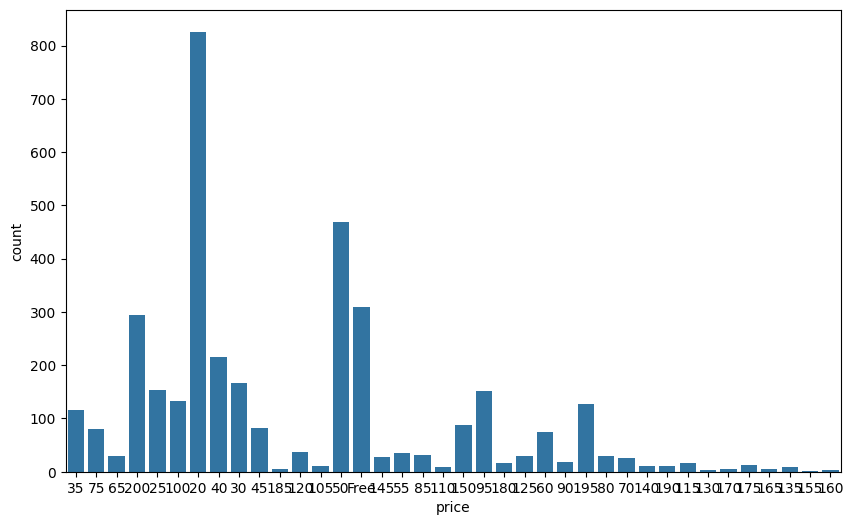

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="price")
plt